# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O Iranian Churn Dataset pertence ao domínio de telecomunicações e foi criado a partir de dados coletados aleatoriamente de uma empresa de telecom iraniana ao longo de 12 meses. O objetivo da base é permitir a análise e a previsão de churn, ou seja, identificar clientes com maior chance de abandonar o serviço. Ela contém 3150 registros, em que cada linha representa um cliente, e reúne informações como falhas em chamadas, quantidade de SMS, reclamações, tempo de assinatura, idade em grupo, valor gasto, tipo de plano, segundos de uso, frequência de uso, status do cliente e valor do cliente. A variável principal é o Churn, que indica se o cliente deixou ou não a empresa ao final do período analisado.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
df.shape

(3150, 14)

In [7]:
TARGET_COLUMN = "Churn"

print(df[TARGET_COLUMN].unique())

[0 1]


O dataframe possui 3150 amostras e 14 colunas ao todo, sendo 13 atributos preditores e 1 variável alvo. A variável alvo é Churn, que indica se o cliente abandonou ou não o serviço da empresa. Observando os valores únicos dessa coluna, temos apenas os valores 0 e 1, em que 0 representa non-churn e 1 representa churn. Portanto, trata-se de um problema de classificação binária, pois o objetivo é prever uma entre duas classes possíveis.(Modifiquei um pouco a resposta que já estava aqui)

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [8]:
df[TARGET_COLUMN].value_counts()

,count
Churn,
0,2655
1,495


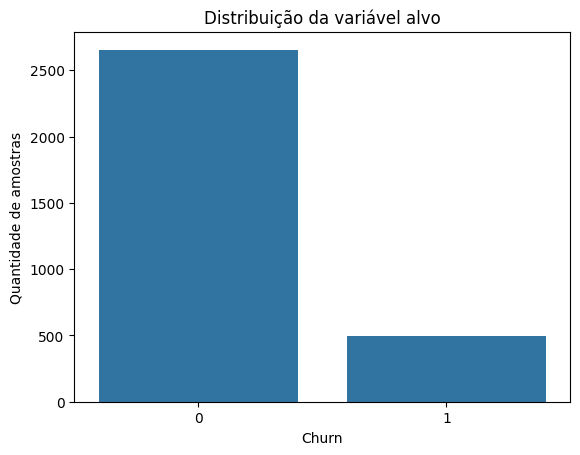

In [9]:
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Distribuição da variável alvo")
plt.xlabel("Churn")
plt.ylabel("Quantidade de amostras")
plt.show()

A variável alvo Churn está desbalanceada. Pela contagem das classes, existem bem mais clientes na classe 0, que representa clientes que não deram churn, do que na classe 1, que representa clientes que deram churn. Isso mostra que o dataset não possui uma proporção parecida entre as duas classes, já que a maioria das amostras pertence à classe 0. Esse desbalanceamento é importante porque o modelo pode acabar aprendendo melhor a identificar clientes que não abandonam o serviço e ter mais dificuldade para identificar corretamente os clientes que realmente dão churn.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

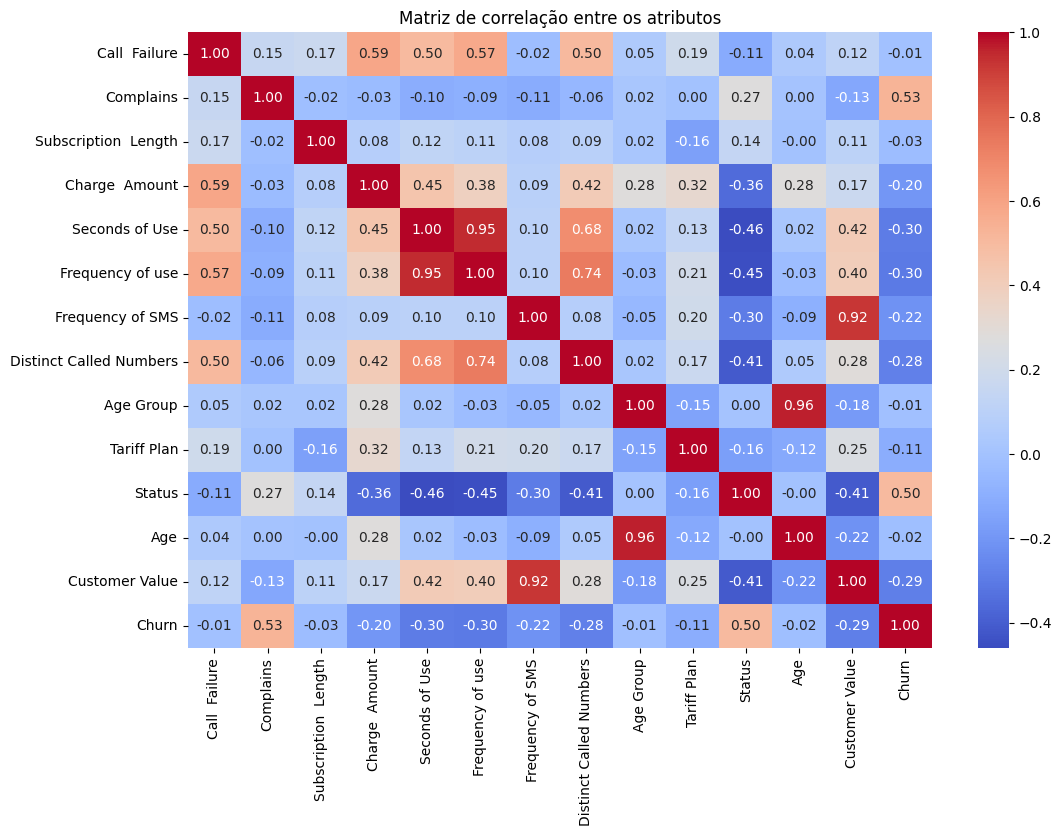

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlação entre os atributos")
plt.show()

In [11]:
corr[TARGET_COLUMN].sort_values(ascending=False)

,Churn
Churn,1.000000
Complains,0.532053
Status,0.498976
Call Failure,-0.008987
Age Group,-0.014550
Age,-0.017705
Subscription Length,-0.032588
Tariff Plan,-0.105853
Charge Amount,-0.202305
Frequency of SMS,-0.220754


Pelos valores da correlação com Churn, os atributos mais relacionados com a variável alvo são Complains e Status, ambos com correlação positiva relativamente alta. Isso indica que clientes que fizeram reclamações e clientes com status não ativo tendem a estar mais associados ao churn. Já as maiores correlações negativas aparecem em Frequency of use, Seconds of Use, Customer Value e Distinct Called Numbers, sugerindo que clientes que usam mais o serviço, fazem mais chamadas e geram maior valor para a empresa tendem a abandonar menos. Então, para o problema de classificação, as variáveis que parecem mais relevantes são principalmente Complains, Status e os atributos ligados ao uso do serviço.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

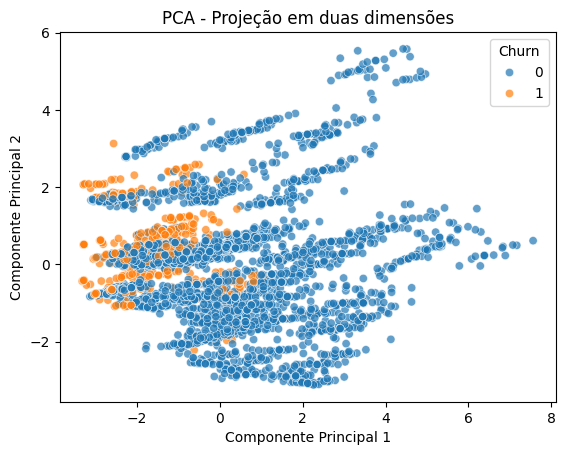

In [12]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[TARGET_COLUMN] = y.values

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COLUMN, alpha=0.7)
plt.title("PCA - Projeção em duas dimensões")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

Pela projeção em duas dimensões usando PCA, não parece existir uma separação totalmente clara entre as classes. Os pontos das classes 0 e 1 aparecem com bastante sobreposição no gráfico, o que indica que apenas as duas primeiras componentes principais não conseguem dividir perfeitamente os clientes que deram churn dos que não deram. Mesmo assim, pode existir uma certa tendência de agrupamento em algumas regiões, mas a separação visual não é forte o suficiente para considerar as classes bem separadas.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [13]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

A padronização é importante porque os atributos estão em escalas muito diferentes, como idade, segundos de uso, quantidade de SMS e valor do cliente. Se isso não for feito, variáveis com valores maiores podem acabar influenciando mais o modelo só por causa da escala. O fit deve ser aplicado apenas no conjunto de treino porque o modelo não pode usar informações do teste durante o treinamento. Depois disso, usamos apenas o transform no teste, mantendo a avaliação mais justa e parecida com um cenário real.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [14]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Iterações usadas:", model.n_iter_[0])
print("Limite máximo de iterações:", model.max_iter)

if model.n_iter_[0] < model.max_iter:
    print("O modelo convergiu corretamente.")
else:
    print("O modelo pode não ter convergido.")

Iterações usadas: 42
Limite máximo de iterações: 1000
O modelo convergiu corretamente.


Nesse caso, a regressão logística foi usada para tentar prever se um cliente vai sair da empresa ou não, com base nas informações disponíveis no dataset. Durante o treinamento, o modelo vai aprendendo quais características aparecem com mais frequência em clientes que deram churn, como reclamações ou status do cliente, e quais aparecem mais em clientes que continuaram usando o serviço. Assim, ele consegue calcular uma tendência/probabilidade de churn para novos clientes.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [15]:
y_proba = model.predict_proba(X_test_scaled)

pd.DataFrame(y_proba, columns=["Probabilidade classe 0", "Probabilidade classe 1"]).head(10)

,Probabilidade classe 0,Probabilidade classe 1
0,0.998819,0.001181
1,0.999954,0.000046
2,0.974259,0.025741
3,0.999518,0.000482
4,0.998645,0.001355
5,0.997155,0.002845
6,0.991459,0.008541
7,0.991455,0.008545
8,0.987025,0.012975
9,0.590190,0.409810


Com base nas probabilidades exibidas, a primeira coluna representa a chance prevista de o cliente pertencer à classe 0 (não churn) e a segunda coluna representa a chance de pertencer à classe 1 (churn). Na maioria dos exemplos, o modelo está prevendo valores muito próximos de 1 para a classe 0 e muito próximos de 0 para a classe 1, como nos primeiros registros, então ele está bastante confiante de que esses clientes não deram churn. Já no último caso mostrado, a previsão ficou mais dividida, com cerca de 59% para classe 0 e 41% para classe 1, então ali o modelo está bem menos confiante, porque as probabilidades ficaram mais próximas uma da outra.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [16]:
proba_churn = y_proba[:, 1]

y_pred_05 = (proba_churn >= 0.5).astype(int)
y_pred_07 = (proba_churn >= 0.7).astype(int)

print("Limiar 0.5")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))

print("\nLimiar 0.7")
print(confusion_matrix(y_test, y_pred_07))
print(classification_report(y_test, y_pred_07))

Limiar 0.5
[[504  16]
 [ 66  44]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       520
           1       0.73      0.40      0.52       110

    accuracy                           0.87       630
   macro avg       0.81      0.68      0.72       630
weighted avg       0.86      0.87      0.85       630


Limiar 0.7
[[514   6]
 [ 74  36]]
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       520
           1       0.86      0.33      0.47       110

    accuracy                           0.87       630
   macro avg       0.87      0.66      0.70       630
weighted avg       0.87      0.87      0.85       630



Com o limiar 0.5, o modelo encontrou 44 clientes churn, mas também marcou 16 clientes como churn sem serem (falsos positivos) e deixou passar 66 clientes que eram churn (falsos negativos). Já com o limiar 0.7, ele ficou mais conservador: os falsos positivos caíram de 16 para 6, mas os falsos negativos aumentaram de 66 para 74. Ou seja, ao aumentar o limiar, o modelo só classifica como churn quando tem mais certeza, melhorando a precision da classe 1 de 0.73 para 0.86, mas piorando o recall de 0.40 para 0.33, porque ele passa a deixar mais clientes churn sem identificar.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [18]:
def avaliar_limiar(y_real, y_pred, limiar):
    print(f"Limiar {limiar}")
    print("Matriz de confusão:")
    print(confusion_matrix(y_real, y_pred))
    print()
    print("Acurácia:", accuracy_score(y_real, y_pred))
    print("Precisão:", precision_score(y_real, y_pred))
    print("Recall:", recall_score(y_real, y_pred))
    print("F1-score:", f1_score(y_real, y_pred))
    print("")

avaliar_limiar(y_test, y_pred_05, 0.5)
avaliar_limiar(y_test, y_pred_07, 0.7)

Limiar 0.5
Matriz de confusão:
[[504  16]
 [ 66  44]]

Acurácia: 0.8698412698412699
Precisão: 0.7333333333333333
Recall: 0.4
F1-score: 0.5176470588235295

Limiar 0.7
Matriz de confusão:
[[514   6]
 [ 74  36]]

Acurácia: 0.873015873015873
Precisão: 0.8571428571428571
Recall: 0.32727272727272727
F1-score: 0.47368421052631576



Comparando os dois resultados, a acurácia ficou praticamente igual, por volta de 87%, então mudar o limiar não alterou muito o desempenho geral. A principal diferença foi na precisão, que aumentou de 0.73 para 0.86 com o limiar 0.7. Isso mostra que, quando o modelo diz que um cliente vai dar churn, ele tende a errar menos. Porém, isso vem com um custo: o recall caiu de 0.40 para 0.33, ou seja, ele passou a identificar menos clientes que realmente deram churn. Na matriz de confusão isso aparece bem: os falsos positivos diminuíram de 16 para 6, mas os falsos negativos aumentaram de 66 para 74. Então, no fim, o limiar 0.7 deixa o modelo mais “cauteloso”, mas também faz ele deixar passar mais casos reais de churn.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O Covertype Dataset é uma base do domínio de biologia/ecologia, voltada para a classificação do tipo de cobertura florestal em áreas do Roosevelt National Forest, no norte do Colorado. O objetivo é prever qual é o tipo de vegetação predominante em uma célula de terreno de 30 x 30 metros, usando apenas variáveis cartográficas, sem imagens de satélite. A base contém informações como elevação, inclinação, aspecto do terreno, sombreamento, distância até rios, estradas e áreas de incêndio, além de dados binários sobre áreas de preservação e tipos de solo. A variável alvo representa o tipo de cobertura florestal, dividido em 7 classes diferentes.

In [19]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [20]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [21]:
df.shape

(58101, 55)

In [22]:
TARGET_COLUMN = "Cover_Type"

df[TARGET_COLUMN].unique()

array([1, 2, 3, 5, 6, 7, 4])

O dataframe possui 58.101 amostras e 55 colunas no total, já considerando que foi usada uma amostra de 10% da base original. Dessas colunas, 54 são atributos de entrada e a variável alvo é Cover_Type. Ao verificar os valores únicos dessa coluna, aparecem as classes 1, 2, 3, 4, 5, 6 e 7, que representam os diferentes tipos de cobertura florestal. Como existem mais de duas classes possíveis, esse é um problema de classificação multiclasse.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [23]:
df[TARGET_COLUMN].value_counts().sort_index()

,count
Cover_Type,
1,21297
2,28248
3,3607
4,259
5,932
6,1706
7,2052


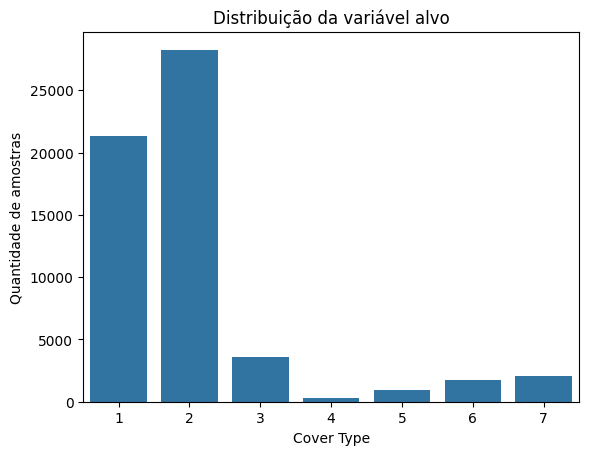

In [24]:
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title("Distribuição da variável alvo")
plt.xlabel("Cover Type")
plt.ylabel("Quantidade de amostras")
plt.show()

Pela distribuição da variável Cover_Type, o dataset está desbalanceado. As classes não aparecem em quantidades parecidas: algumas têm muitas amostras, principalmente as classes mais frequentes, enquanto outras aparecem bem menos. Isso significa que o modelo pode acabar aprendendo melhor as classes maiores e tendo mais dificuldade para acertar as classes com poucos exemplos. Portanto, mesmo sendo um problema multiclasse, a proporção entre as classes não está equilibrada.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

In [25]:
corr_target = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN)
corr_target_sorted = corr_target.sort_values()

corr_target_sorted

,Cover_Type
Elevation,-0.268264
Wilderness_Area1,-0.200715
Horizontal_Distance_To_Roadways,-0.155258
Soil_Type22,-0.140253
Soil_Type23,-0.133668
Soil_Type29,-0.123732
Horizontal_Distance_To_Fire_Points,-0.109868
Hillshade_Noon,-0.094159
Soil_Type32,-0.078483
Soil_Type24,-0.065993


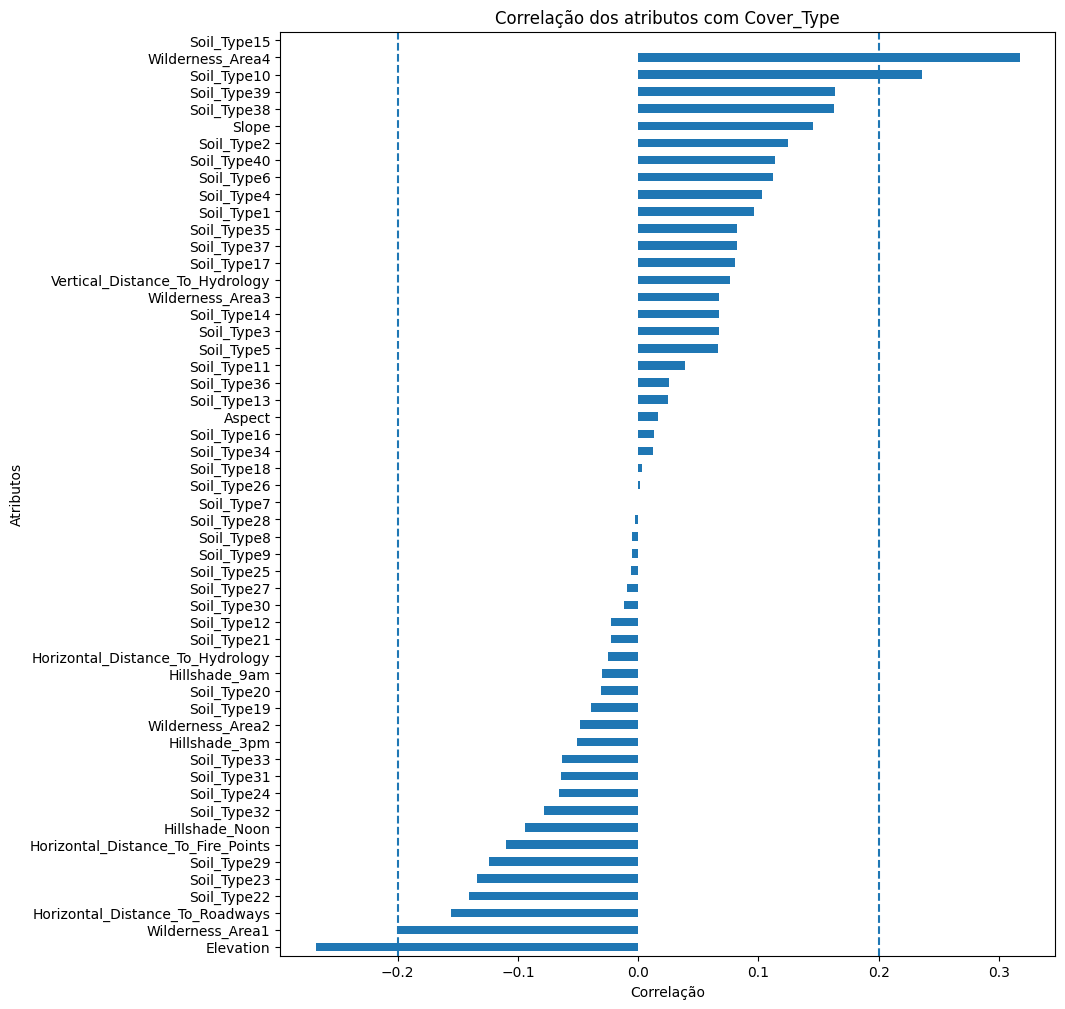

In [26]:
plt.figure(figsize=(10, 12))

corr_target_sorted.plot(kind="barh")

plt.axvline(0.2, linestyle="--")
plt.axvline(-0.2, linestyle="--")

plt.title("Correlação dos atributos com Cover_Type")
plt.xlabel("Correlação")
plt.ylabel("Atributos")
plt.show()

Pelo gráfico, as variáveis que mais chamam atenção são Wilderness_Area4, Elevation, Soil_Type10 e Wilderness_Area1, porque foram as que passaram ou chegaram bem perto do limite de |r| = 0.2. A Wilderness_Area4 teve a maior correlação positiva, enquanto Elevation teve a maior correlação negativa. Então, olhando só por essa análise inicial, parece que a região da floresta, o tipo de solo e a elevação do terreno podem ter mais peso para diferenciar os tipos de cobertura florestal. Como é um problema multiclasse, essa correlação não explica tudo sozinha, mas já dá uma ideia de quais atributos podem ser mais importantes.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

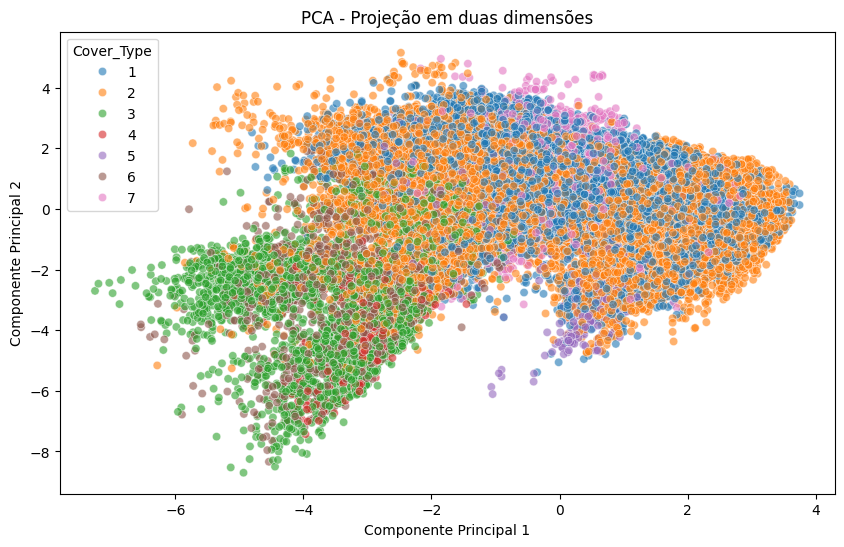

In [27]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[TARGET_COLUMN] = y.values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=TARGET_COLUMN,
    palette="tab10",
    alpha=0.6
)

plt.title("PCA - Projeção em duas dimensões")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

Pela visualização do PCA, dá para ver que as classes não ficam totalmente separadas. Algumas regiões até parecem ter maior concentração de certos tipos de cobertura, mas ainda existe bastante sobreposição entre os pontos de classes diferentes. Isso mostra que só as duas primeiras componentes principais não conseguem separar bem todas as classes do dataset. Então, o modelo provavelmente vai precisar usar mais informações dos atributos originais para conseguir diferenciar melhor os tipos de cobertura florestal.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [28]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

A validação cruzada com KFold é importante porque ela avalia o modelo em várias divisões diferentes dos dados, em vez de depender de uma única separação entre treino e teste. Assim, dá para ter uma ideia mais confiável do desempenho, já que o resultado não fica tão preso a uma divisão específica que poderia ter ficado “mais fácil” ou “mais difícil”. Com 5 divisões, o modelo é treinado e validado em partes diferentes da base, ajudando a perceber se ele está realmente generalizando bem ou se só funcionou bem em uma separação específica dos dados.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [30]:
acc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    scaler_fold = StandardScaler()
    X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train)
    X_fold_val_scaled = scaler_fold.transform(X_fold_val)

    model_fold = LogisticRegression(max_iter=1000, random_state=42)
    model_fold.fit(X_fold_train_scaled, y_fold_train)

    y_fold_pred = model_fold.predict(X_fold_val_scaled)

    acc_scores.append(accuracy_score(y_fold_val, y_fold_pred))
    precision_scores.append(precision_score(y_fold_val, y_fold_pred, average="macro", zero_division=0))
    recall_scores.append(recall_score(y_fold_val, y_fold_pred, average="macro", zero_division=0))
    f1_scores.append(f1_score(y_fold_val, y_fold_pred, average="macro", zero_division=0))

    print(f"Fold {fold}")
    print("Iterações usadas:", model_fold.n_iter_)

    if max(model_fold.n_iter_) < model_fold.max_iter:
        print("Convergiu corretamente")
    else:
        print("Pode não ter convergido")

    print("")

print("Média das métricas:")
print("Acurácia:", np.mean(acc_scores))
print("Precisão:", np.mean(precision_scores))
print("Recall:", np.mean(recall_scores))
print("F1-score:", np.mean(f1_scores))

Fold 1
Iterações usadas: [184]
Convergiu corretamente

Fold 2
Iterações usadas: [179]
Convergiu corretamente

Fold 3
Iterações usadas: [217]
Convergiu corretamente

Fold 4
Iterações usadas: [205]
Convergiu corretamente

Fold 5
Iterações usadas: [180]
Convergiu corretamente

Média das métricas:
Acurácia: 0.7259466437177281
Precisão: 0.5890223622946793
Recall: 0.5026237432323853
F1-score: 0.522603977596349


O modelo convergiu corretamente nos 5 folds, já que em todos eles o número de iterações ficou bem abaixo do limite de 1000. A média de acurácia foi 0.726, então o modelo acertou cerca de 72,6% das previsões. Porém, as métricas macro ficaram mais baixas, principalmente o recall de 0.503 e o F1-score de 0.523, indicando que o desempenho não foi igual para todas as classes. Isso provavelmente acontece porque algumas classes têm bem menos amostras que outras. Nesse problema, a regressão logística está tentando aprender a relação entre características do terreno, como elevação, solo, inclinação e distância até estradas ou rios, para prever o tipo de cobertura florestal.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [31]:
final_model = LogisticRegression(C=0.01, max_iter=1000, random_state=42)

final_model.fit(X_train_scaled, y_train)

y_proba = final_model.predict_proba(X_test_scaled)

proba_df = pd.DataFrame(
    y_proba,
    columns=[f"Classe {classe}" for classe in final_model.classes_]
)

proba_df.head(10)

,Classe 1,Classe 2,Classe 3,Classe 4,Classe 5,Classe 6,Classe 7
0,0.456718,0.523084,0.000064,0.000090,0.003085,0.000088,0.016871
1,0.038392,0.450021,0.152924,0.000451,0.013272,0.344410,0.000530
2,0.224398,0.734051,0.003887,0.000330,0.021610,0.011459,0.004264
3,0.237865,0.745048,0.000941,0.000087,0.011288,0.002022,0.002749
4,0.115367,0.728307,0.007653,0.000130,0.034959,0.113243,0.000341
5,0.598901,0.389038,0.000043,0.000037,0.001486,0.000146,0.010349
6,0.386811,0.597203,0.001345,0.000070,0.004976,0.003742,0.005852
7,0.240762,0.741702,0.000431,0.000106,0.014718,0.000629,0.001651
8,0.473949,0.519709,0.000124,0.000075,0.001559,0.000342,0.004242
9,0.000430,0.049232,0.717409,0.010652,0.002515,0.219762,0.000001


Cada coluna da tabela representa a probabilidade de uma amostra pertencer a uma das classes de Cover_Type. Por exemplo, a coluna Classe 1 mostra a chance prevista de aquele terreno ser da classe 1, a Classe 2 mostra a chance de ser da classe 2, e assim por diante. Como é um problema multiclasse, a soma das probabilidades em cada linha fica próxima de 1, e o modelo escolhe como previsão final a classe com maior probabilidade. Quando uma linha tem uma probabilidade muito alta em uma classe, como algo perto de 0.90, o modelo está mais confiante. Já quando as probabilidades ficam mais divididas entre várias classes, a previsão é menos segura, porque o modelo não conseguiu diferenciar tão bem aquele exemplo.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [32]:
model_sem_reg = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

model_sem_reg.fit(X_train_scaled, y_train)

y_proba_sem_reg = model_sem_reg.predict_proba(X_test_scaled)

proba_sem_reg_df = pd.DataFrame(
    y_proba_sem_reg,
    columns=[f"Classe {classe}" for classe in model_sem_reg.classes_]
)

proba_sem_reg_df.head(10)

,Classe 1,Classe 2,Classe 3,Classe 4,Classe 5,Classe 6,Classe 7
0,4.779047e-01,0.512566,1.215503e-08,1.450274e-08,1.659997e-03,4.642122e-09,7.868828e-03
1,3.109225e-02,0.429935,1.073498e-01,1.490047e-06,1.295030e-02,4.186708e-01,2.538197e-09
2,1.993353e-01,0.775794,9.012523e-04,4.874699e-07,2.257777e-02,1.317988e-03,7.351994e-05
3,2.155095e-01,0.771856,9.517771e-07,1.472775e-07,1.239896e-02,1.371806e-04,9.732805e-05
4,1.009095e-01,0.762008,3.635516e-03,1.013747e-06,3.051376e-02,1.029321e-01,1.488697e-07
5,6.328878e-01,0.358900,4.750063e-09,9.669349e-10,6.664802e-04,4.877268e-09,7.545315e-03
6,3.876715e-01,0.607608,1.360361e-04,2.124222e-07,3.825414e-03,4.457652e-04,3.132896e-04
7,2.229160e-01,0.762972,1.361985e-07,2.278046e-11,1.401508e-02,5.441223e-08,9.657432e-05
8,4.605671e-01,0.538920,9.640051e-07,4.283471e-08,2.903764e-06,1.457271e-07,5.090766e-04
9,8.670166e-09,0.008674,7.359574e-01,1.092123e-02,1.764148e-07,2.444470e-01,2.978682e-16


Sem regularização, o modelo ficou mais “decidido” em algumas previsões. Em várias amostras, ele jogou a maior parte da probabilidade para uma classe só, principalmente para a Classe 2. Mesmo assim, nem todas as previsões ficaram tão claras: nas amostras 0 e 8, por exemplo, ele ficou bem dividido entre as classes 1 e 2, então a confiança não foi tão alta. Na amostra 9, a Classe 3 teve a maior probabilidade, mas a Classe 6 também apareceu com um valor considerável. Então, comparando de forma geral, tirar a regularização deixou o modelo um pouco mais confiante em alguns casos, mas isso não quer dizer automaticamente que ele ficou melhor, porque ele também pode acabar se ajustando demais aos dados de treino.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [33]:
conf_reg = y_proba.max(axis=1)
conf_sem_reg = y_proba_sem_reg.max(axis=1)

print("Confiança média com regularização:", conf_reg.mean())
print("Confiança média sem regularização:", conf_sem_reg.mean())

Confiança média com regularização: 0.7024909029483848
Confiança média sem regularização: 0.7275706595353355


In [34]:
comparacao_conf = pd.DataFrame({
    "conf_com_regularizacao": conf_reg,
    "conf_sem_regularizacao": conf_sem_reg
})

comparacao_conf.head(10)

,conf_com_regularizacao,conf_sem_regularizacao
0,0.523084,0.512566
1,0.450021,0.429935
2,0.734051,0.775794
3,0.745048,0.771856
4,0.728307,0.762008
5,0.598901,0.632888
6,0.597203,0.607608
7,0.741702,0.762972
8,0.519709,0.538920
9,0.717409,0.735957


Comparando os dois modelos, o sem regularização ficou um pouco mais confiante nas previsões. Isso aparece na confiança média, que foi de 0.702 com regularização e 0.728 sem regularização. Ou seja, sem a regularização, o modelo tende a concentrar mais probabilidade em uma classe só. Isso aparece em exemplos como as amostras 2, 3, 4, 7 e 9, em que a confiança sem regularização ficou maior. Mesmo assim, a diferença não foi tão grande. O ponto principal é que essa confiança maior não significa automaticamente um modelo melhor, porque sem regularização ele pode ficar mais “preso” aos dados de treino, o que pode ser um indício de overfitting. Já a regularização deixa o modelo um pouco mais controlado e menos extremo nas probabilidades.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [35]:
y_pred_reg = final_model.predict(X_test_scaled)
y_pred_sem_reg = model_sem_reg.predict(X_test_scaled)

print("Modelo com regularização L2")
print(classification_report(y_test, y_pred_reg, zero_division=0))

print("\nModelo sem regularização")
print(classification_report(y_test, y_pred_sem_reg, zero_division=0))

Modelo com regularização L2
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621


Modelo sem regularização
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           6       0.47 

Comparando os dois modelos, o desempenho geral ficou bem parecido: o modelo com regularização teve 72% de acurácia, enquanto o modelo sem regularização ficou com 73%. Nas classes maiores, como 1 e 2, quase não houve diferença, com F1-score perto de 0.70 e 0.78. A maior mudança apareceu nas classes menores. A classe 4, por exemplo, melhorou bastante sem regularização, saindo de F1-score 0.17 para 0.43. A classe 6 também melhorou, de 0.20 para 0.30, e a classe 7 teve uma pequena melhora. Por outro lado, a classe 5 continuou muito ruim nos dois modelos, com recall de apenas 0.01, ou seja, quase nunca foi identificada corretamente. No geral, o modelo sem regularização teve um resultado um pouco melhor nas métricas macro, principalmente por melhorar algumas classes menores, mas ainda existe dificuldade clara nas classes com poucas amostras.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

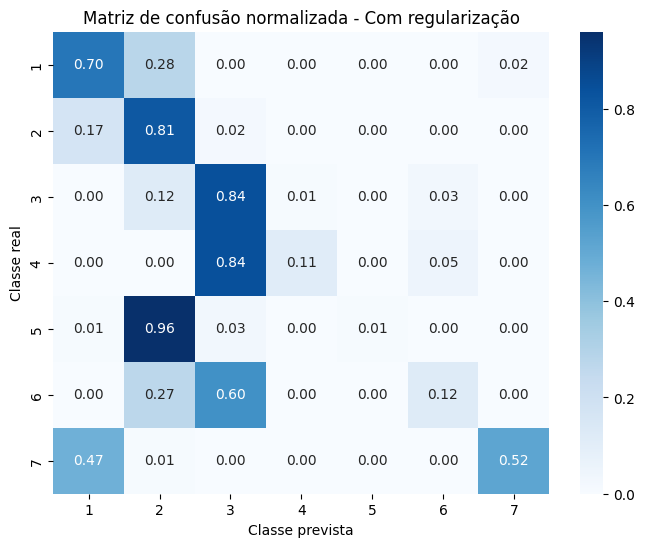

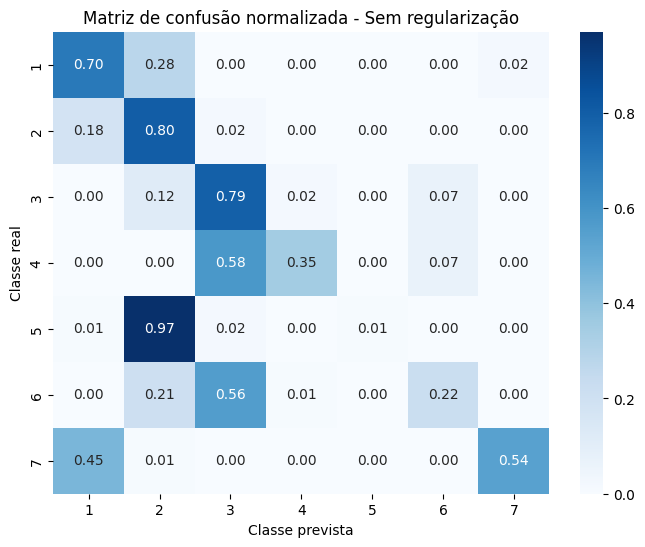

In [36]:
cm_reg = confusion_matrix(y_test, y_pred_reg, normalize="true")
cm_sem_reg = confusion_matrix(y_test, y_pred_sem_reg, normalize="true")

cm_reg = np.round(cm_reg, 2)
cm_sem_reg = np.round(cm_sem_reg, 2)

classes = final_model.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_reg, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusão normalizada - Com regularização")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sem_reg, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de confusão normalizada - Sem regularização")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.show()

Comparando as duas matrizes, as classes 1 e 2 ficaram praticamente iguais nos dois modelos, com acertos em torno de 0.70 e 0.80/0.81. A classe 3 foi melhor com regularização, subindo de 0.79 para 0.84, então nesse caso a regularização ajudou. Já nas classes menores, principalmente 4 e 6, o modelo sem regularização foi melhor: a classe 4 passou de 0.11 para 0.35, e a classe 6 passou de 0.12 para 0.22. A classe 5 continuou muito ruim nos dois casos, sendo quase sempre confundida com a classe 2. No geral, a regularização deixou o modelo mais “seguro” para algumas classes maiores, mas acabou piorando a identificação de algumas classes menores. Já o modelo sem regularização conseguiu recuperar melhor essas classes menores, mesmo mantendo algumas confusões fortes, principalmente entre 4 e 3, 5 e 2, e 6 com 3/2.